In [1]:
import pandas as pd
import plotly.express as pe
import re
import os

In [2]:
report = pd.read_parquet("./test_data/report.parquet")
report["Identifier"] = report["Run"].apply(lambda x: re.search("AL000028_S_([A-Za-z]\\d)", x).group(1))

In [3]:
report.columns

Index(['Run.Index', 'Run', 'Channel', 'Precursor.Id', 'Modified.Sequence',
       'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Lib.Index', 'Decoy',
       'Proteotypic', 'Precursor.Mz', 'Protein.Ids', 'Protein.Group',
       'Protein.Names', 'Genes', 'RT', 'iRT', 'Predicted.RT', 'Predicted.iRT',
       'IM', 'iIM', 'Predicted.IM', 'Predicted.iIM', 'Precursor.Quantity',
       'Precursor.Normalised', 'Ms1.Area', 'Ms1.Normalised', 'Ms1.Apex.Area',
       'Ms1.Apex.Mz.Delta', 'Normalisation.Factor', 'Quantity.Quality',
       'Empirical.Quality', 'Normalisation.Noise', 'Ms1.Profile.Corr',
       'Evidence', 'Mass.Evidence', 'Channel.Evidence',
       'Ms1.Total.Signal.Before', 'Ms1.Total.Signal.After', 'RT.Start',
       'RT.Stop', 'FWHM', 'PG.TopN', 'PG.MaxLFQ', 'Genes.TopN', 'Genes.MaxLFQ',
       'Genes.MaxLFQ.Unique', 'PG.MaxLFQ.Quality', 'Genes.MaxLFQ.Quality',
       'Genes.MaxLFQ.Unique.Quality', 'Q.Value', 'PEP', 'Global.Q.Value',
       'Lib.Q.Value', 'Peptidoform.Q.Value'

In [4]:
precursor_charge_data = (
    report
    .groupby(["Identifier", "Precursor.Charge"])
    .size()
    .reset_index(name="counts")
)

precursor_charge_data["Percent of Precursors"] = (
    precursor_charge_data["counts"] /
    precursor_charge_data.groupby("Identifier")["counts"].transform("sum")
) * 100

precursor_charge_data["Precursor.Charge"] = precursor_charge_data["Precursor.Charge"].apply(lambda x: str(x))

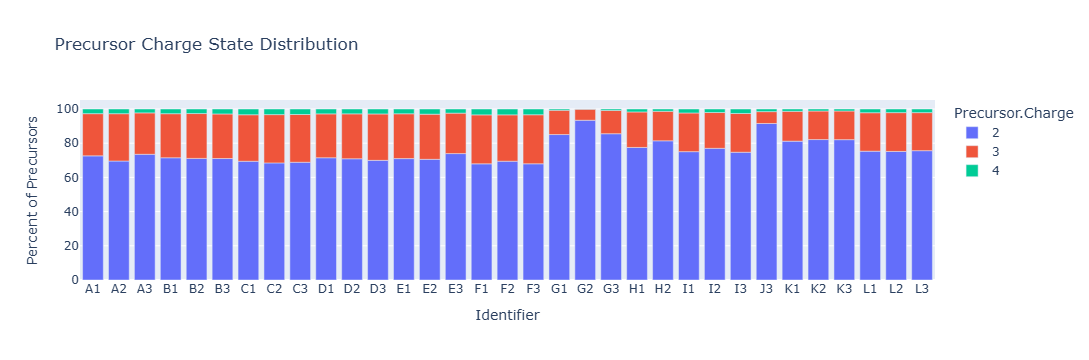

In [5]:
pe.bar(precursor_charge_data, x = "Identifier", y="Percent of Precursors", color = "Precursor.Charge", title = "Precursor Charge State Distribution")

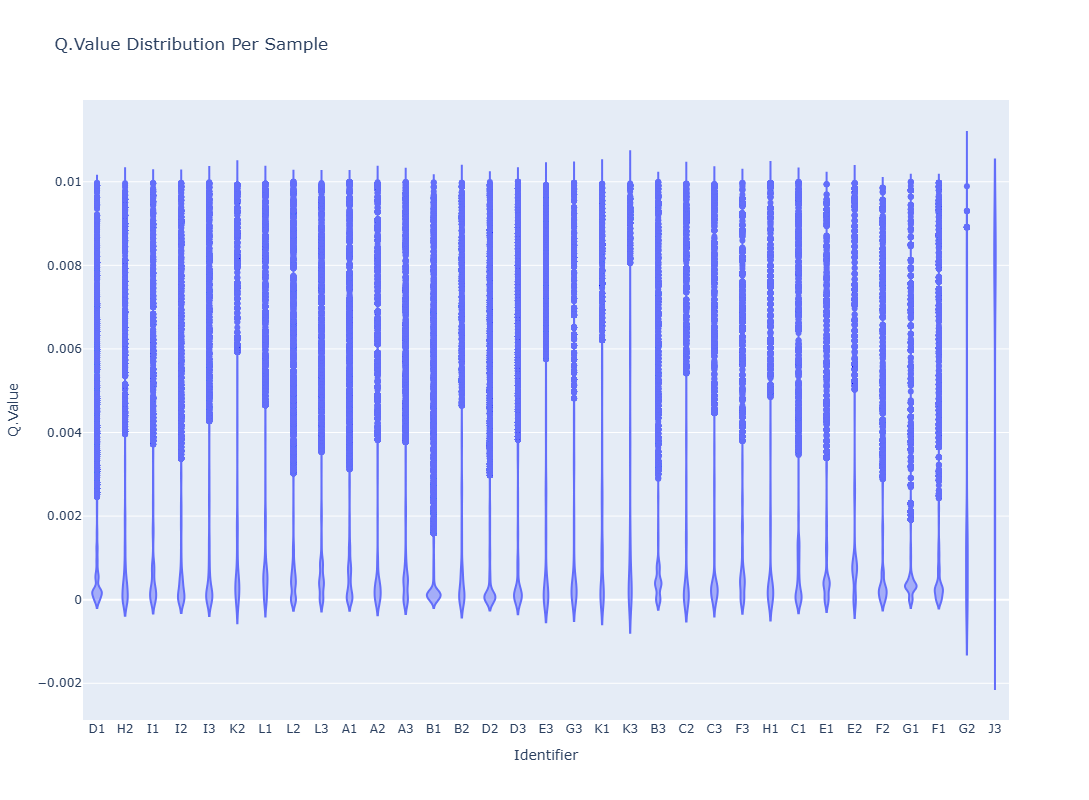

In [6]:
pe.violin(
    report, x="Identifier", y="Q.Value",height = 800,
    title = "Q.Value Distribution Per Sample"
)

In [14]:
from utils.helpers import analyze_missed_cleavages

In [15]:
mc = analyze_missed_cleavages(report)["by_identifier"]

In [20]:
mc_dataset_wide = analyze_missed_cleavages(report)["by_missed_cleavages"]

In [21]:
mc_dataset_wide

,mc_category,mc_label,peptide_count,percent
0,0,pct_mc0,319143,90.89
1,1,pct_mc1,29278,8.34
2,2,pct_mc2,2702,0.77
3,3,pct_mc3,0,0.00
4,3+,pct_mc3+,0,0.00


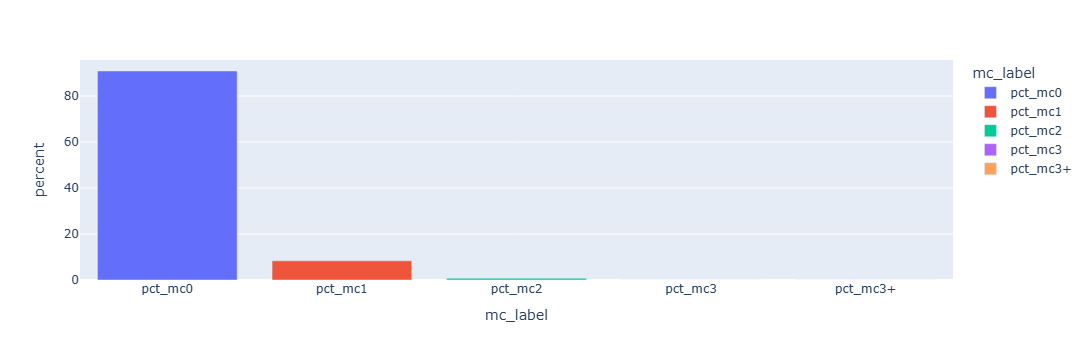

In [24]:
pe.bar(mc_dataset_wide, x = "mc_label", y = "percent", color = "mc_label")

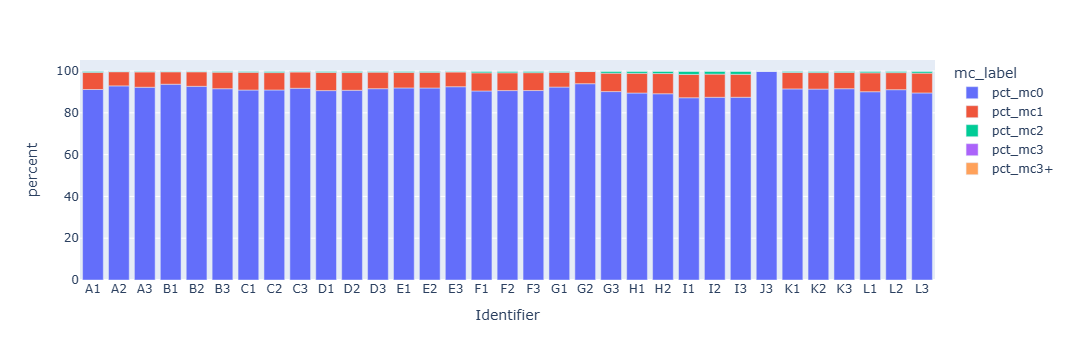

In [17]:
pe.bar(mc, x="Identifier", y="percent", color="mc_label")